company_total_conflicts {'google': 3, 'microsoft': 420}
--- Conflict Report ---
Repos with ≥1 conflict: 4 | Total conflicts: 423
Repos with ≥5 conflicts: 3

--- Company-wise Conflict Report ---
google: Attempts (repos) = 4 | Repos with ≥1 conflict = 1 | Repos with ≥5 conflicts = 0 | Total conflicts = 3
microsoft: Attempts (repos) = 40 | Repos with ≥1 conflict = 3 | Repos with ≥5 conflicts = 3 | Total conflicts = 420


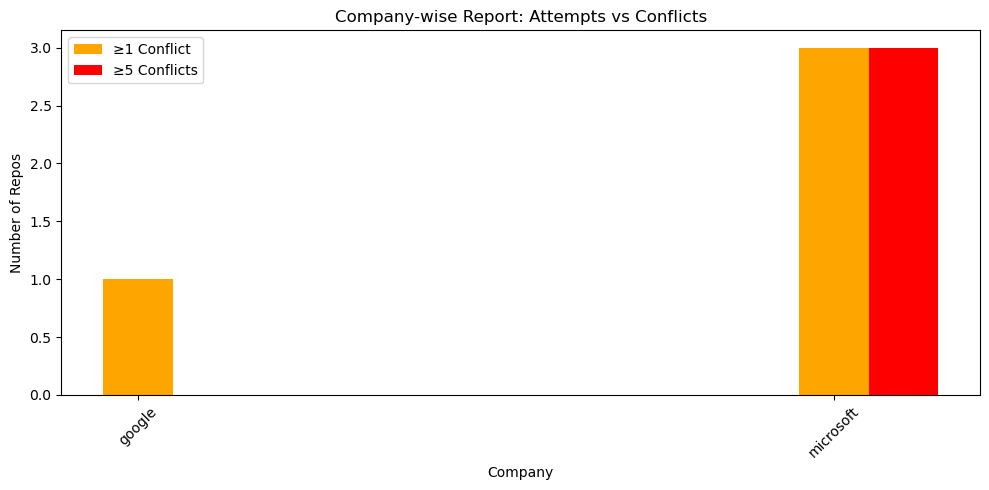

In [2]:
import matplotlib.pyplot as plt
from collections import defaultdict
from db_operations import get_db_conn

conn = get_db_conn()
cur = conn.cursor()

# Get processed repos per company (aka "attempts")
cur.execute("""
    SELECT LOWER(organization), COUNT(*) 
    FROM searchrepos 
    WHERE is_active = FALSE 
    GROUP BY LOWER(organization);
""")
company_attempts = {row[0]: row[1] for row in cur.fetchall()}

# Get all repos with conflicts >= 1
cur.execute("""
    SELECT LOWER(organization), COUNT(*), SUM(license_conflicts)
    FROM searchrepos
    WHERE is_active = FALSE AND license_conflicts >= 1
    GROUP BY LOWER(organization);
""")
conflict_rows = cur.fetchall()

company_conflict_1plus = {row[0]: row[1] for row in conflict_rows}
company_total_conflicts = {row[0]: row[2] for row in conflict_rows}

print("company_total_conflicts", company_total_conflicts)
# Get all repos with conflicts >= 5
cur.execute("""
    SELECT LOWER(organization), COUNT(*)
    FROM searchrepos
    WHERE is_active = FALSE AND license_conflicts >= 5
    GROUP BY LOWER(organization);
""")
company_conflict_5plus = {row[0]: row[1] for row in cur.fetchall()}

cur.close()
conn.close()

# Aggregated counts
repos_1plus = sum(company_conflict_1plus.values())
repos_5plus = sum(company_conflict_5plus.values())
total_conflict_1plus = sum(company_total_conflicts.get(org, 0) for org in company_conflict_1plus)

# total_conflict_5plus isn't precomputed, but you can fetch that if needed separately.

# Print results
print(f"--- Conflict Report ---")
print(f"Repos with ≥1 conflict: {repos_1plus} | Total conflicts: {total_conflict_1plus}")
print(f"Repos with ≥5 conflicts: {repos_5plus}")

companies = sorted(set(company_attempts) | set(company_conflict_1plus) | set(company_conflict_5plus))

print(f"\n--- Company-wise Conflict Report ---")
for company in companies:
    attempts = company_attempts.get(company, 0)
    c1 = company_conflict_1plus.get(company, 0)
    c5 = company_conflict_5plus.get(company, 0)
    total_conflicts = company_total_conflicts.get(company, 0)
    print(f"{company}: Attempts (repos) = {attempts} | Repos with ≥1 conflict = {c1} | Repos with ≥5 conflicts = {c5} | Total conflicts = {total_conflicts}")

# Visualization
x = range(len(companies))
width = 0.1
repos_1plus_counts = [company_conflict_1plus.get(c, 0) for c in companies]
repos_5plus_counts = [company_conflict_5plus.get(c, 0) for c in companies]
attempt_counts = [company_attempts.get(c, 0) for c in companies]

plt.figure(figsize=(10, 5))
# plt.bar([i - width for i in x], attempt_counts, width=width, label='Attempts Made', color='gray')
plt.bar(x, repos_1plus_counts, width=width, label='≥1 Conflict', color='orange')
plt.bar([i + width for i in x], repos_5plus_counts, width=width, label='≥5 Conflicts', color='red')

plt.xlabel('Company')
plt.ylabel('Number of Repos')
plt.title('Company-wise Report: Attempts vs Conflicts')
plt.xticks(x, companies, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
import re
import pandas as pd

# Path to your directory
dir_path = "../shell_scripts/results"

# Match files that end with a number greater than 0
def valid_csv(filename):
    match = re.search(r'_(\d+)\.csv$', filename)
    return match and int(match.group(1)) > 0

# List all matching CSVs
csv_files = [os.path.join(dir_path, f) for f in os.listdir(dir_path)
             if f.endswith(".csv") and valid_csv(f)]

# Read and concatenate
df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

# Filter: query_project == 'Yes' and violation contains 'incompatible'
filtered = df[
    (df['query_project'] == 'Yes') &
    (df['violation'].str.contains('incompatible', case=False, na=False))
]

# Get hashes of the filtered set
hashes_to_keep = filtered['hash'].unique()

# Keep all rows where hash is in the filtered set
final_df = df[df['hash'].isin(hashes_to_keep)].reset_index(drop=True)

final_df = final_df[final_df['violation'] != 'Undetermined']

# Optional: reset index
final_df = final_df.reset_index(drop=True)

##############

# Make sure 'version' is numeric so sorting works as expected
final_df['version'] = pd.to_numeric(final_df['version'], errors='coerce')

# Sort by 'hash' and 'version'
final_df = final_df.sort_values(by=['hash', 'version'])

# Create a flag column for first appearance of each hash
final_df['is_first_hash'] = ~final_df.duplicated(subset='hash', keep='first')

final_df = final_df[
    (final_df['query_project'] == 'Yes') |
    (final_df['is_first_hash'])
].reset_index(drop=True)

final_df = final_df.drop(columns=['function_code'], errors='ignore')

In [8]:
final_df.shape

(10788, 12)

In [9]:
final_df.to_csv("../results/violations_examples.csv", index=False)

In [1]:
import os
import re
import pandas as pd

# Path to your directory
dir_path = "../shell_scripts/results"

# Match files that end with a number greater than 0
def valid_csv(filename):
    match = re.search(r'_(\d+)\.csv$', filename)
    return match and int(match.group(1)) > 0

all_filtered = []
# Collect valid CSVs
csv_files = [f for f in os.listdir(dir_path) if valid_csv(f)]

for f in csv_files:
    df = pd.read_csv(os.path.join(dir_path, f))
    df = df.groupby('hash').filter(
    lambda group: (
        (group['query_project'] == "Yes") &
        (~group['function_code'].str.contains("Error fetching code", na=False)) &
        (group['violation'].str.contains("incompatible", case=False, na=False))
    ).any()
    )

    df = df.groupby('hash').filter(
        lambda group: ~(
            (group['query_project'] == "1") &
            (group['function_code'].str.contains("Error fetching code", na=False))
        ).any()
    )

    df["organization"]= f.split("_")[0]
    all_filtered.append(df)
df = pd.concat(all_filtered, ignore_index=True)
df.sort_values(by=["organization", "hash"],inplace=True)

unique_orgs = df['organization'].unique()
print("Unique organizations:")
for org in unique_orgs:
    print("-", org)
# Display or save
df.to_csv("../results/filtered_violation_results.csv", index=False)

Unique organizations:
- google
- intel
- microsoft


In [2]:
print(len(df))

126


In [1]:
import pandas as pd
from db_operations import get_db_conn

def count_stats():
    conn = get_db_conn()
    cur = conn.cursor()

    query = """
    SELECT
        LOWER(organization) AS organization,
        COUNT(DISTINCT repository_url) AS total_projects,
        (
            COALESCE(SUM(same_license), 0) +
            COALESCE(SUM(dif_license_comply), 0) +
            COALESCE(SUM(license_conflicts), 0) +
            COALESCE(SUM(high_risks), 0) +
            COALESCE(SUM(undetermined), 0) +
            COALESCE(SUM(no_match), 0)
        ) AS total_methods,
        SUM(same_license) AS same_license,
        SUM(dif_license_comply) AS diff_license_comply,
        SUM(license_conflicts) AS license_conflicts,
        SUM(high_risks) AS high_risks,
        SUM(undetermined) AS undetermined,
        SUM(no_match) AS no_match
    FROM searchrepos
    WHERE is_active = FALSE
    GROUP BY LOWER(organization);
    """

    cur.execute(query)
    rows = cur.fetchall()
    columns = [desc[0] for desc in cur.description]

    df = pd.DataFrame(rows, columns=columns)

    # Add percentage columns with formatted output
    categories = [
        "same_license", "diff_license_comply", "license_conflicts",
        "high_risks", "undetermined", "no_match"
    ]

    for cat in categories:
        df[cat] = df.apply(
            lambda row: f"{row[cat]} ({(row[cat] / row['total_methods'] * 100):.1f}%)" if row['total_methods'] > 0 else f"{row[cat]} (0.0%)",
            axis=1
        )

    # Save to CSV
    df.to_csv("org_license_stats.csv", index=False)
    print("\nSaved to 'org_license_stats.csv'")

    cur.close()
    conn.close()
    return df

# Run it
count_stats()


Saved to 'org_license_stats.csv'


,organization,total_projects,total_methods,same_license,diff_license_comply,license_conflicts,high_risks,undetermined,no_match
0,google,110,17549,1807 (10.3%),2235 (12.7%),7350 (41.9%),5034 (28.7%),5 (0.0%),1118 (6.4%)
1,ibm,176,10091,1650 (16.4%),2116 (21.0%),2381 (23.6%),3565 (35.3%),4 (0.0%),375 (3.7%)
2,intel,90,14952,1996 (13.3%),567 (3.8%),762 (5.1%),7412 (49.6%),0 (0.0%),4215 (28.2%)
3,microsoft,156,11435,1122 (9.8%),608 (5.3%),851 (7.4%),6558 (57.4%),17 (0.1%),2279 (19.9%)


In [2]:
from db_operations import get_db_conn

def fetch_undetermined_records():
    conn = get_db_conn()
    cur = conn.cursor()

    query = """
        SELECT *
        FROM searchrepos
        WHERE undetermined > 0;
    """
    
    cur.execute(query)
    rows = cur.fetchall()

    for row in rows:
        print(row)

    cur.close()
    conn.close()

# Run it
fetch_undetermined_records()

('20250715184702688950_67151f', 'Microsoft', '3630062502', '1730414456000', 'https://github.com/microsoft/tslib', 'BSD Zero Clause License', 'TypeScript', 0, 0, 0, 0, 14, 1, True, False, None, None)
('20250715184702823437_e62d97', 'IBM', '1771281843', '1733220703000', 'https://github.com/IBM/ibm-cos-sdk-python-core', 'Apache License 2.0', 'Python', 15, 123, 35, 535, 3, 134, True, False, None, None)
('20250715184702685837_132f2d', 'Microsoft', '1554964069', '1641786441000', 'https://github.com/microsoft/php-sdk-binary-tools', 'BSD 2-Clause "Simplified" License', 'M4', 0, 0, 0, 0, 2, 0, True, False, None, None)
('20250715184702686998_4185b1', 'Microsoft', '3509902151', '1662004847000', 'https://github.com/microsoft/dotnet-samples', 'MIT License', 'C#', 29, 1, 1, 8, 1, 27, True, False, None, None)
('20250715184702762271_9df103', 'Google', '2129307436', '1733819116000', 'https://github.com/google/traceur-compiler', 'Apache License 2.0', 'JavaScript', 39, 437, 54, 433, 1, 0, True, False, No

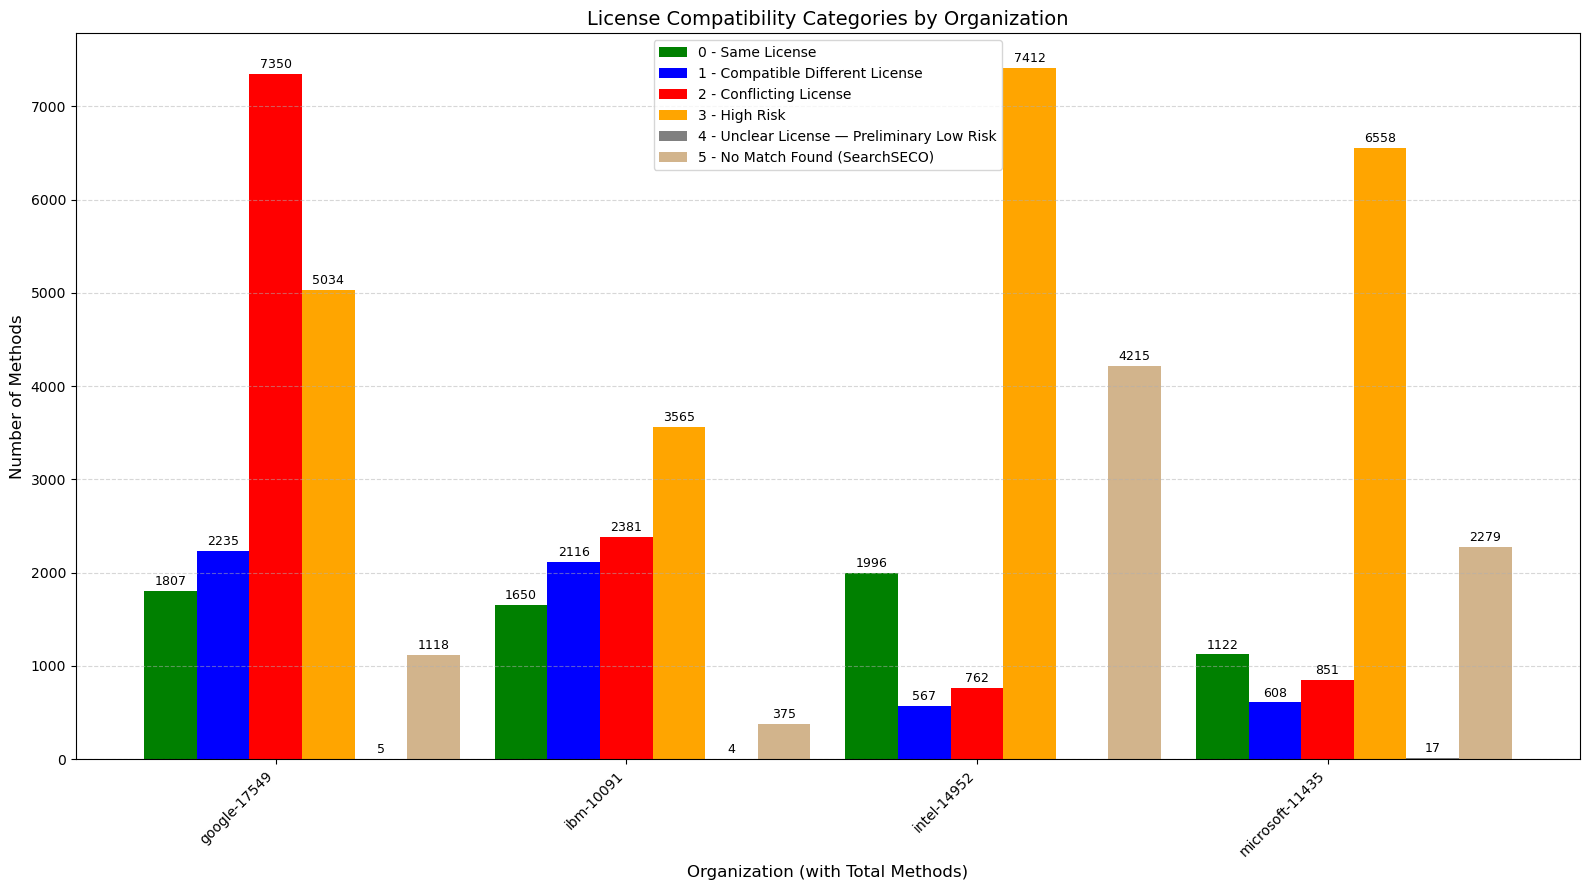

In [3]:
import matplotlib.pyplot as plt
from db_operations import get_db_conn

def fetch_license_category_counts():
    conn = get_db_conn()
    cur = conn.cursor()

    # Fetch category counts and total method count per organization
    cur.execute("""
        SELECT
            LOWER(organization),
            SUM(same_license) AS cat0,
            SUM(dif_license_comply) AS cat1,
            SUM(license_conflicts) AS cat2,
            SUM(high_risks) AS cat3,
            SUM(undetermined) AS cat4,
            SUM(no_match) AS cat5,
            (
                COALESCE(SUM(same_license), 0) +
                COALESCE(SUM(dif_license_comply), 0) +
                COALESCE(SUM(license_conflicts), 0) +
                COALESCE(SUM(high_risks), 0) +
                COALESCE(SUM(undetermined), 0) +
                COALESCE(SUM(no_match), 0)
            ) AS total_methods
        FROM searchrepos
        WHERE is_active = FALSE
        GROUP BY LOWER(organization);
    """)

    company_category_data = {}
    for row in cur.fetchall():
        org = row[0]
        company_category_data[org] = {
            0: row[1] or 0,
            1: row[2] or 0,
            2: row[3] or 0,
            3: row[4] or 0,
            4: row[5] or 0,
            5: row[6] or 0,
            'total_methods': row[7]
        }

    cur.close()
    conn.close()
    return company_category_data

def plot_license_categories(company_category_data):
    companies = sorted(company_category_data.keys())
    x = range(len(companies))
    width = 0.15

    # Extract data per category
    category_0 = [company_category_data[c][0] for c in companies]
    category_1 = [company_category_data[c][1] for c in companies]
    category_2 = [company_category_data[c][2] for c in companies]
    category_3 = [company_category_data[c][3] for c in companies]
    category_4 = [company_category_data[c][4] for c in companies]
    category_5 = [company_category_data[c][5] for c in companies]
    total_methods = [company_category_data[c]['total_methods'] for c in companies]

    # Append total_methods to company labels
    labels = [f"{c}-{total_methods[i]}" for i, c in enumerate(companies)]

    plt.figure(figsize=(16, 9))
    bars0 = plt.bar([i - 2*width for i in x], category_0, width=width, label='0 - Same License', color='green')
    bars1 = plt.bar([i - width for i in x], category_1, width=width, label='1 - Compatible Different License', color='blue')
    bars2 = plt.bar(x, category_2, width=width, label='2 - Conflicting License', color='red')
    bars3 = plt.bar([i + width for i in x], category_3, width=width, label='3 - High Risk', color='orange')
    bars4 = plt.bar([i + 2*width for i in x], category_4, width=width, label='4 - Unclear License — Preliminary Low Risk', color='gray')
    bars5 = plt.bar([i + 3*width for i in x], category_5, width=width, label='5 - No Match Found (SearchSECO)', color='tan')

    # Helper to annotate bars
    def annotate_bars(bars):
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                plt.text(bar.get_x() + bar.get_width()/2, height + 30, f'{int(height)}',
                         ha='center', va='bottom', fontsize=9)

    # Annotate each bar group
    for bars in [bars0, bars1, bars2, bars3, bars4, bars5]:
        annotate_bars(bars)

    plt.xlabel('Organization (with Total Methods)', fontsize=12)
    plt.ylabel('Number of Methods', fontsize=12)
    plt.title('License Compatibility Categories by Organization', fontsize=14)
    plt.xticks(x, labels, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

# Run
company_category_data = fetch_license_category_counts()
plot_license_categories(company_category_data)
